In [1]:
import random

users = []

for i in range(1, 11):
    user = {
        "user_id": i,
        "daily_app_opens": random.randint(1, 20),
        "avg_session_duration": round(random.uniform(2, 60), 2)
    }
    users.append(user)

print("Random User Dataset:")
for user in users:
    print(user)

Random User Dataset:
{'user_id': 1, 'daily_app_opens': 8, 'avg_session_duration': 39.77}
{'user_id': 2, 'daily_app_opens': 6, 'avg_session_duration': 41.9}
{'user_id': 3, 'daily_app_opens': 17, 'avg_session_duration': 2.02}
{'user_id': 4, 'daily_app_opens': 12, 'avg_session_duration': 51.93}
{'user_id': 5, 'daily_app_opens': 9, 'avg_session_duration': 6.69}
{'user_id': 6, 'daily_app_opens': 20, 'avg_session_duration': 58.42}
{'user_id': 7, 'daily_app_opens': 20, 'avg_session_duration': 59.32}
{'user_id': 8, 'daily_app_opens': 4, 'avg_session_duration': 35.88}
{'user_id': 9, 'daily_app_opens': 3, 'avg_session_duration': 45.29}
{'user_id': 10, 'daily_app_opens': 11, 'avg_session_duration': 2.96}


q-2. supervised learning:-
->Learns from data containing known labels/target values.
->Requires labeled data.
->Prediction or classification.
->Examples: Linear regression, logistic regression, decision trees, support vector machines, neural networks.

=> unsupervised learning:-
->Learns from data without known labels/target values.
->Does not require labeled data.
->Clustering or dimensionality reduction.
->Examples: K-means clustering, hierarchical clustering, principal component analysis (PCA), autoencoders.

  Product  Price  Reviews  Cluster
0      P1    999      850        0
1      P2    499      920        0
2      P3    399      780        0
3      P4   3999      420        2
4      P5   3499      380        2
5      P6  55000      150        1
6      P7  75000       95        1
7      P8  12999      210        2


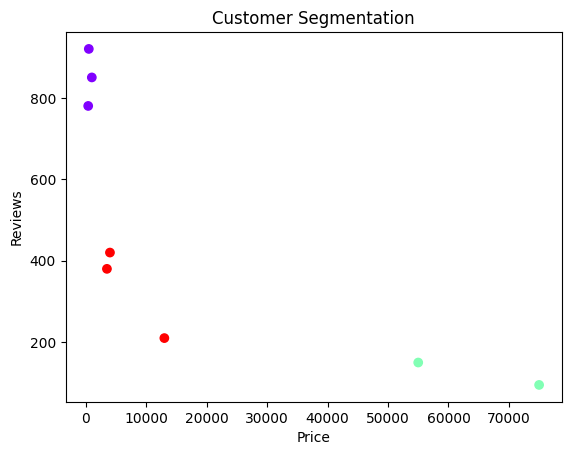

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Sample data

data = {
    "Product": ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"],
    "Price": [999, 499, 399, 3999, 3499, 55000, 75000, 12999],
    "Reviews": [850, 920, 780, 420, 380, 150, 95, 210]
}

df = pd.DataFrame(data)

# Features used for clustering
X = df[["Price", "Reviews"]]

# Scale the features because price and reviews have different ranges
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df)

plt.scatter(df["Price"], df["Reviews"], c=df["Cluster"], cmap="rainbow")
plt.xlabel("Price")
plt.ylabel("Reviews")
plt.title("Customer Segmentation")
plt.show()

Scenario 1 – Zomato Customer Segmentation
Objective

Group customers according to their food-ordering behavior.

Data Required

Possible features:

Number of orders
Average order value
Ordering frequency
Delivery location
Average restaurant rating
Weekend vs. weekday orders
Discount usage
Possible Clusters
Cluster 1 → Frequent high-value customers
Cluster 2 → Occasional budget customers
Cluster 3 → Discount-focused customers
Insight

Zomato could use these groups to provide personalized offers.

For example:

High-value customers → premium restaurant recommendations
Budget customers → affordable meal offers
Discount-focused users → coupon-based campaigns


Scenario 2 – Flipkart Product Segmentation
Objective

Group products according to their price and customer behavior.

Data Required
Product price
Number of reviews
Average rating
Number of purchases
Return rate
Discount percentage
Product category
Possible Clusters
Cluster 1 → Low-price, high-demand products
Cluster 2 → Medium-price, moderate-demand products
Cluster 3 → Premium, low-volume products
Insight

Flipkart could discover which products are:

Budget-friendly and popular
Premium products

Scenario 3 – Spotify Listener Segmentation
Objective

Group users according to their listening behavior.

Data Required
Songs played
Listening duration
Favorite genres
Skip rate
Number of playlists
Listening frequency
Artists followed
Time of listening
Possible Clusters
Cluster 1 → Heavy daily listeners
Cluster 2 → Casual listeners
Cluster 3 → Genre-specific listeners
Insight

Spotify could use these clusters to:

Recommend personalized playlists.
Recommend new artists.

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape: (20, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Customer Segments:
    CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0            1                  15                      39        0
1            2                  15                      81        4
2            3                  16                       6        0
3            4                  16                      77        4
4            5                  17                      40      

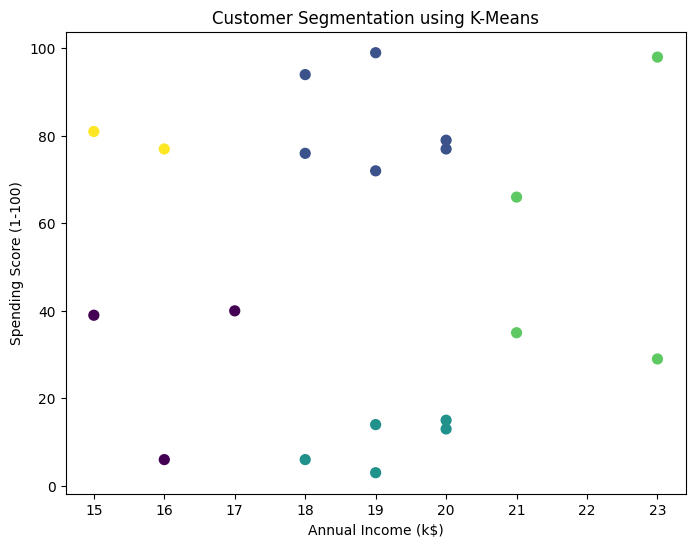

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("/content/sample_data/Mall_Customers (1).csv")

# Display first 5 rows
print(df.head())

# Display dataset information
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

# Select features for clustering
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Assign cluster to each customer
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Display results
print("\nCustomer Segments:")
print(df[[
    "CustomerID",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster"
]].head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=50
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.show()